<a href="https://colab.research.google.com/github/zencod-646/Deeplearning/blob/main/featurecheck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
#!unzip modulated\ vowels



In [36]:
import os
print (os.listdir("/content"))

['.config', 'modulated vowels.zip', 'modulated vowels', 'sample_data']


In [37]:
print (os.listdir("/content/modulated vowels/hc/A"))


['AVPEPUDEAC0010_a.wav', 'AVPEPUDEAC0052_a.wav', 'AVPEPUDEAC0037_a.wav', 'AVPEPUDEAC0027_a.wav', 'AVPEPUDEAC0013_a.wav', 'AVPEPUDEAC0042_a.wav', 'AVPEPUDEAC0057_a.wav', 'AVPEPUDEAC0025_a.wav', 'AVPEPUDEAC0007_a.wav', 'AVPEPUDEAC0041_a.wav', 'AVPEPUDEAC0053_a.wav', 'AVPEPUDEAC0035_a.wav', 'AVPEPUDEAC0004_a.wav', 'AVPEPUDEAC0050_a.wav', 'AVPEPUDEAC0039_a.wav', 'AVPEPUDEAC0005_a.wav', 'AVPEPUDEAC0018_a.wav', 'AVPEPUDEAC0043_a.wav', 'AVPEPUDEAC0011_a.wav', 'AVPEPUDEAC0047_a.wav', 'AVPEPUDEAC0022_a.wav', 'AVPEPUDEAC0045_a.wav', 'AVPEPUDEAC0014_a.wav', 'AVPEPUDEAC0015_a.wav', 'AVPEPUDEAC0028_a.wav', 'AVPEPUDEAC0008_a.wav', 'AVPEPUDEAC0017_a.wav', 'AVPEPUDEAC0024_a.wav', 'AVPEPUDEAC0021_a.wav', 'AVPEPUDEAC0048_a.wav', 'AVPEPUDEAC0031_a.wav', 'AVPEPUDEAC0003_a.wav', 'AVPEPUDEAC0001_a.wav', 'AVPEPUDEAC0033_a.wav', 'AVPEPUDEAC0034_a.wav', 'AVPEPUDEAC0044_a.wav', 'AVPEPUDEAC0023_a.wav', 'AVPEPUDEAC0030_a.wav', 'AVPEPUDEAC0020_a.wav', 'AVPEPUDEAC0054_a.wav', 'AVPEPUDEAC0051_a.wav', 'AVPEPUDEAC0019

In [38]:
import os
for roots,dirs,files in os.walk("/content/modulated vowels"):
   for file in files :
    if file.endswith(".wav"):
      path = os.path.join(roots,file)
      print (path)

/content/modulated vowels/hc/U/AVPEPUDEAC0019_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0044_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0051_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0021_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0031_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0018_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0054_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0034_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0012_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0045_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0040_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0041_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0022_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0006_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0047_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0014_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0025_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0049_u.wav
/content/modulated vowels/hc/U/AVPEPUDEAC0028_u.wav
/content/mod

In [39]:
import librosa
hc_file = "/content/modulated vowels/hc/A/AVPEPUDEAC0001_a.wav"
pd_file = "/content/modulated vowels/pd/A/AVPEPUDEA0001_a.wav"

hc_audio,sr1 = librosa.load(hc_file,sr = None)
pd_audio,sr2 = librosa.load(pd_file , sr = None)
print ("HC duration:", len(hc_audio)/sr1)
print ("PD duration:", len(pd_audio)/sr2)

HC duration: 2.204421768707483
PD duration: 4.924036281179139


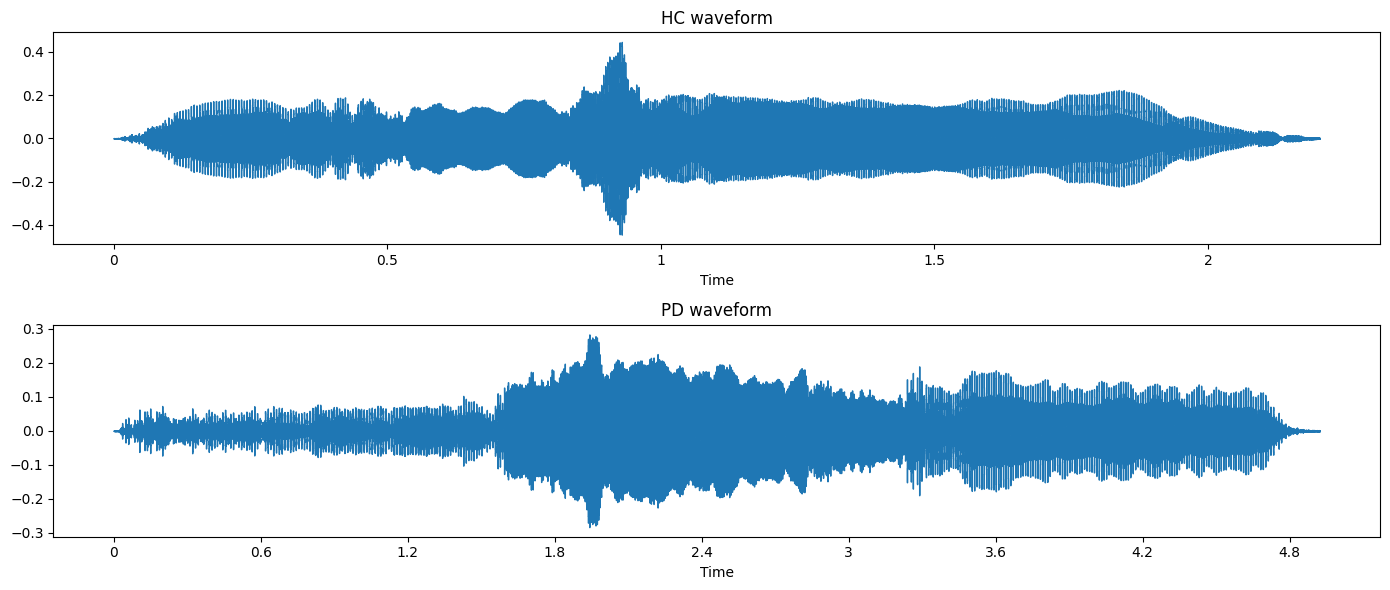

In [40]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

plt.figure(figsize=(14,6))
plt.subplot(2,1,1)
librosa.display.waveshow(hc_audio,sr=sr1)
plt.title("HC waveform")

plt.subplot(2,1,2)
librosa.display.waveshow(pd_audio,sr=sr2)
plt.title("PD waveform")
plt.tight_layout()
plt.show()

In [41]:
from IPython.display import Audio, display

TARGET_DURATION = 3

hc_target = int(sr1 * TARGET_DURATION)

pd_target = int(sr2 * TARGET_DURATION)

hc_audio = librosa.util.fix_length(
    hc_audio,
    size=hc_target
)

pd_audio = librosa.util.fix_length(
    pd_audio,
    size=pd_target
)

print()

print("HC padded duration:",
      len(hc_audio)/sr1)

print("PD padded duration:",
      len(pd_audio)/sr2)


# ==========================
# LISTEN TO AUDIO
# ==========================

display(Audio(
    hc_audio,
    rate=sr1
))

display(Audio(
    pd_audio,
    rate=sr2
))


HC padded duration: 3.0
PD padded duration: 3.0


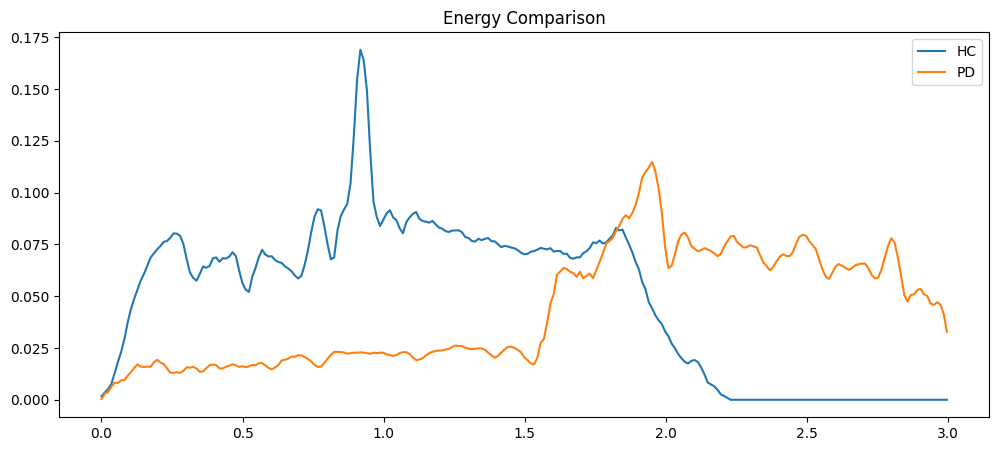

In [42]:
hc_rms = librosa.feature.rms(y=hc_audio)[0]

pd_rms = librosa.feature.rms(y=pd_audio)[0]

hc_t = librosa.times_like(hc_rms,sr=sr1)

pd_t = librosa.times_like(pd_rms,sr=sr2)

plt.figure(figsize=(12,5))

plt.plot(hc_t,hc_rms,label="HC")

plt.plot(pd_t, pd_rms,label="PD")

plt.legend()

plt.title("Energy Comparison")

plt.show()

In [43]:
hc_mfcc = librosa.feature.mfcc(
    y=hc_audio,
    sr=sr1,
    n_mfcc=13
)

pd_mfcc = librosa.feature.mfcc(
    y=pd_audio,
    sr=sr2,
    n_mfcc=13
)

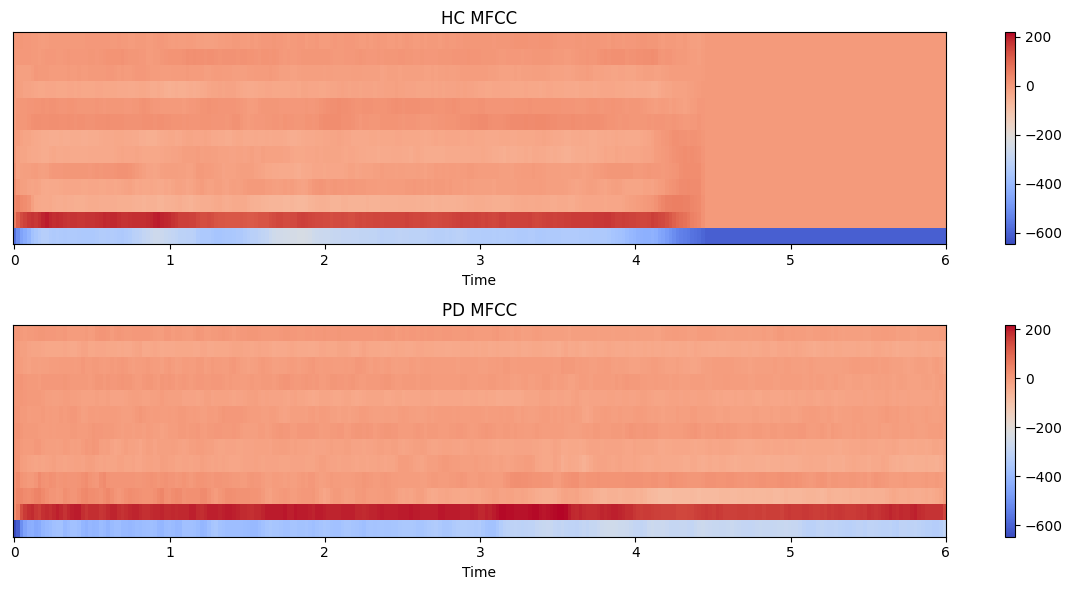

In [44]:
vmin = min(hc_mfcc.min(), pd_mfcc.min())
vmax = max(hc_mfcc.max(), pd_mfcc.max())

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)

librosa.display.specshow(
    hc_mfcc,
    x_axis='time',
    vmin=vmin,
    vmax=vmax
)

plt.colorbar()
plt.title("HC MFCC")

plt.subplot(2,1,2)

librosa.display.specshow(
    pd_mfcc,
    x_axis='time',
    vmin=vmin,
    vmax=vmax
)

plt.colorbar()
plt.title("PD MFCC")

plt.tight_layout()
plt.show()

In [45]:
print("HC mean energy:", np.mean(hc_rms))
print("PD mean energy:", np.mean(pd_rms))

print("HC std energy:", np.std(hc_rms))
print("PD std energy:", np.std(pd_rms))

HC mean energy: 0.049275544
PD mean energy: 0.042898312
HC std energy: 0.037609186
PD std energy: 0.02728866


In [46]:
hc_delta = librosa.feature.delta(hc_mfcc)

pd_delta = librosa.feature.delta(pd_mfcc)

print(np.mean(hc_delta))

print(np.mean(pd_delta))

-0.06188239
0.024883999
